In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
import sys
print(sys.executable)

/home/user_stel/miniconda3/bin/python


### Load Data

In [2]:
# find path where data is stored 
path_to_dev = "../data/assignment1_dev_set.csv"
path_to_val = "../data/assignment1_val_set.csv"

# load data into pd dataframes 
dev_set_df = pd.read_csv(path_to_dev)
val_set_df = pd.read_csv(path_to_val)

# display df contents 
print("Development Data :")
print(dev_set_df.head())
print("\nEvaluation Data Head:")
print(val_set_df.head())

# information 
print("Development Data Info:")
print(dev_set_df.info())
print(list(dev_set_df.columns))

Development Data :
   Unnamed: 0   Project ID Experiment type     Sex  Host age    BMI  \
0           0   PRJEB11419    Metagenomics    Male      53.0  19.01   
1           1  PRJNA388263    Metagenomics  Female      21.0  23.50   
2           2  PRJNA388263    Metagenomics    Male      52.0  25.80   
3           3   PRJEB11419    Metagenomics  Female      40.0  23.49   
4           4   PRJEB11419    Metagenomics  Female      30.0  22.60   

  Disease MESH ID  Acholeplasma axanthum  Acidaminococcus fermentans  \
0         D006262               0.000000                    0.000000   
1         D006262               0.001028                    0.000000   
2         D006262               0.001406                    0.000000   
3         D006262               0.000000                    0.008825   
4         D006262               0.002878                    0.037419   

   Acidaminococcus intestini  ...  Clostridium sphenoides  \
0                   0.000000  ...                0.005891   

### Preprocessing

In [3]:
# Removal of unnecessary columns 
# Unnamed:0, Project ID, Experiment type, Sex, Host age
unnecessary_columns=['Unnamed: 0', 'Project ID', 'Experiment type', 'Sex', 'Disease MESH ID']

dev_set_cleaned_df=dev_set_df.drop(columns=unnecessary_columns)
val_set_cleaned_df=val_set_df.drop(columns=unnecessary_columns)

print("Development Data after Preprocessing:")
print(dev_set_cleaned_df.head())

# Check for missing values 
dev_set_missing_df=dev_set_cleaned_df.isnull().sum()
print("Missing Values:")
print(dev_set_missing_df)

# Save Pandas Dataframes as CSV files
dev_set_cleaned_df.to_csv('development_final_data.csv')
val_set_cleaned_df.to_csv('evaluation_final_data.csv')

Development Data after Preprocessing:
   Host age    BMI  Acholeplasma axanthum  Acidaminococcus fermentans  \
0      53.0  19.01               0.000000                    0.000000   
1      21.0  23.50               0.001028                    0.000000   
2      52.0  25.80               0.001406                    0.000000   
3      40.0  23.49               0.000000                    0.008825   
4      30.0  22.60               0.002878                    0.037419   

   Acidaminococcus intestini  Actinomyces lingnae  Akkermansia muciniphila  \
0                   0.000000             0.000000                 0.017674   
1                   0.000000             0.000000                13.015800   
2                   0.000000             0.001406                 0.002812   
3                   0.273562             0.000000                 0.044123   
4                   7.359970             0.000000                 0.872143   

   Alistipes finegoldii  Alistipes indistinctus  Alist

## Pearson's Correlation Coefficients

Highly correlated pairs:
Streptococcus mitis              Streptococcus oralis                       0.984661
Hungatella hathewayi             Lachnospiraceae bacterium 3_1_57FAA_CT1    0.980509
Bacteroides graminisolvens       Prevotella ruminicola                      0.910267
Prevotella bivia                 Prevotella shahii                          0.906563
Porphyromonas catoniae           Streptococcus mitis                        0.875085
Bacteroides intestinalis         Ruminococcaceae bacterium D16              0.864316
Bacillus megaterium              Clostridium amylolyticum                   0.860058
Anaerostipes butyraticus         Anaerostipes caccae                        0.851647
Porphyromonas catoniae           Streptococcus oralis                       0.832220
Actinomyces lingnae              Fusobacterium nucleatum                    0.805016
Blautia glucerasea               Ruminococcus gnavus                        0.755592
Clostridium asparagiforme        Clostri

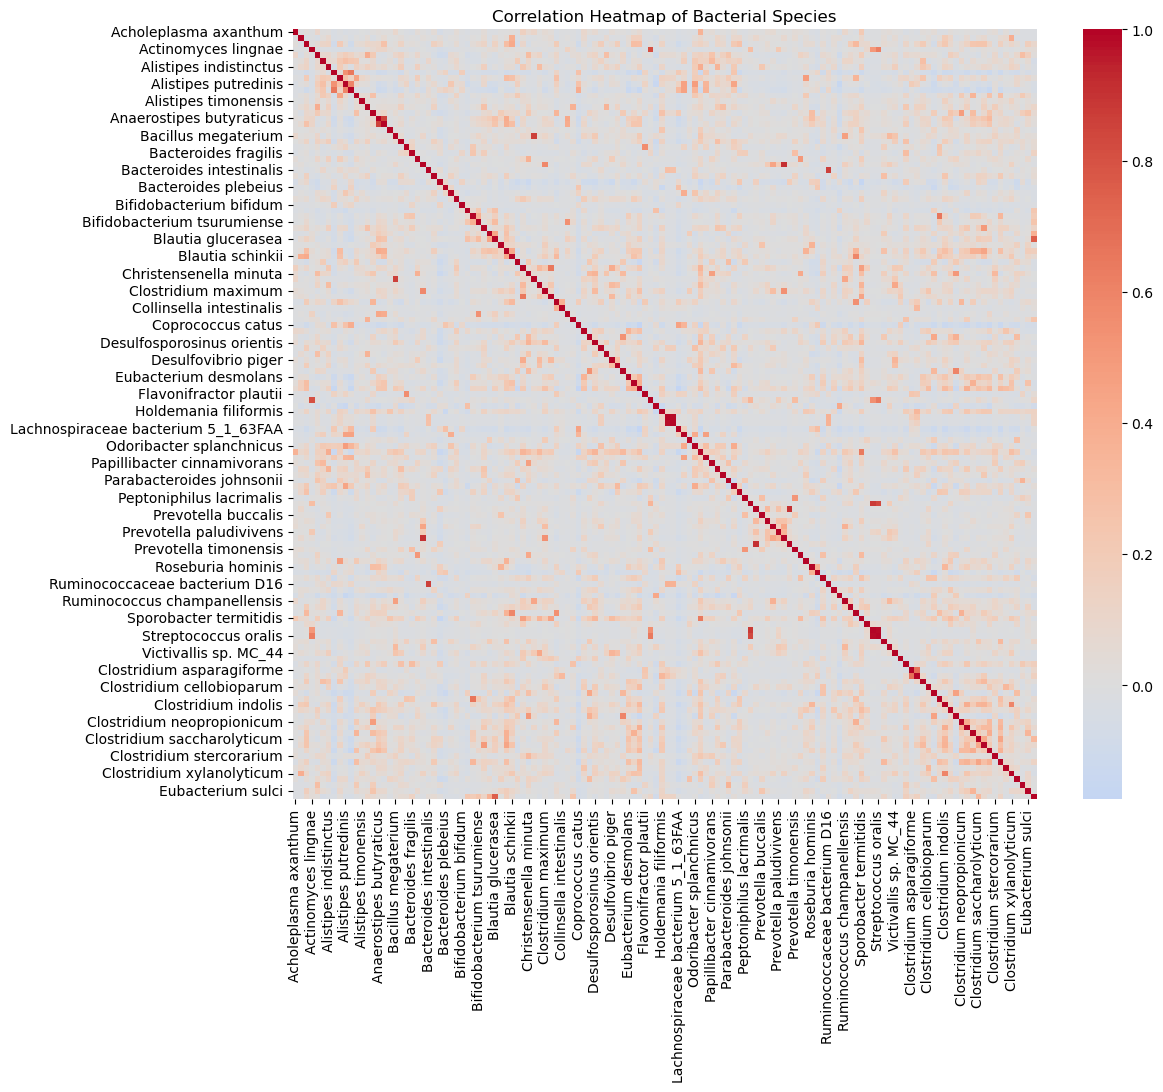

In [ ]:
# Pearson's Correlation Coefficient for Bacteria species 
# Check for high correlation between bacteria species in order to exclude some of the species and reduce dimensionality 
bacteria_species=dev_set_cleaned_df.columns.drop(['BMI', 'Host age'])
correlation_matrix=dev_set_cleaned_df[bacteria_species].corr(method='pearson')

threshold = 0.5
high_corr_pairs = (
    correlation_matrix.abs()
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

high_corr_pairs = high_corr_pairs[high_corr_pairs > threshold]

print("Highly correlated pairs:")
print(high_corr_pairs)

# Species to remove (second species in each pair)
species_to_remove = set()

for pair in high_corr_pairs.index:
    species_to_remove.add(pair[1])

print("Species to remove:", species_to_remove)

# Drop highly correlated species
dev_set_cleaned_reduced_df = dev_set_cleaned_df.drop(columns=species_to_remove)
print(f"Reduced from {len(dev_set_cleaned_df.columns)} to {len(dev_set_cleaned_reduced_df.columns)} columns.")

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Bacterial Species')
plt.show()

### Data Visualization